In [27]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [6]:
df=pd.read_csv("./CSVs/Titanic-Dataset.csv",usecols=["Age","Fare","Survived"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [9]:
df['Age'].fillna(df['Age'].mean,inplace=True)

In [10]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [14]:
X=df.drop(["Survived"],axis=1)
Y=df.Survived
colsx=X.columns

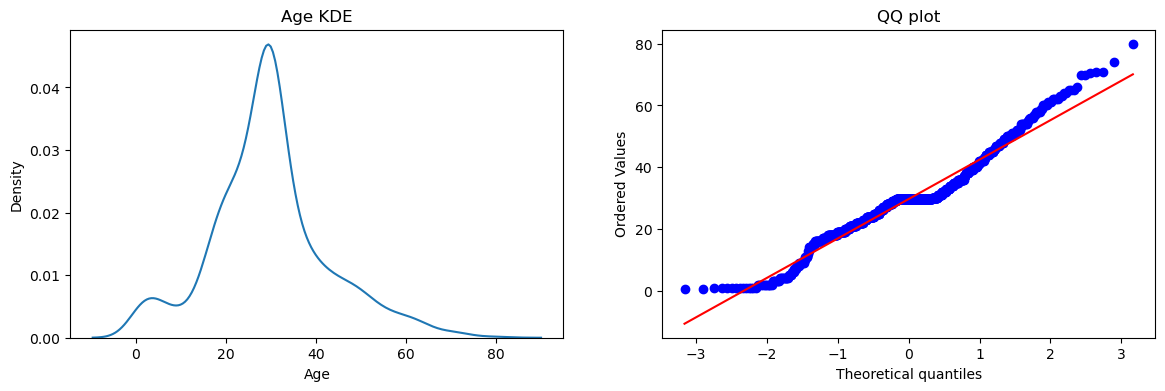

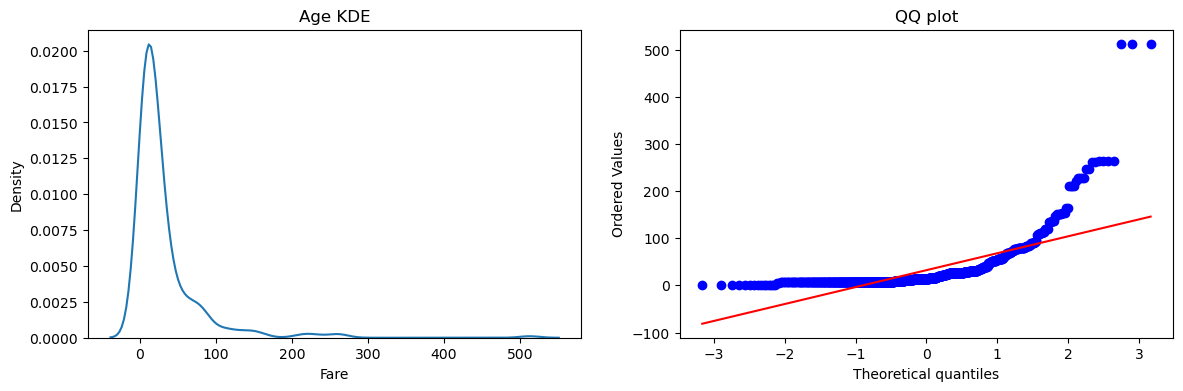

In [20]:
for i in colsx: 
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X[i])
    plt.title("Age KDE")

    plt.subplot(122)
    stats.probplot(X[i],dist='norm',plot=plt)
    plt.title("QQ plot")

In [22]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

In [23]:
mod1=LogisticRegression()
mod2=DecisionTreeClassifier()

In [24]:
mod1.fit(X_train,Y_train)
mod2.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
pred1=mod1.predict(X_test)
pred2=mod2.predict(X_test)

In [28]:
print("Accuracy of LR :",accuracy_score(Y_test,pred1))
print("Accuracy of DTC",accuracy_score(Y_test,pred2))


Accuracy of LR : 0.6312849162011173
Accuracy of DTC 0.5921787709497207


In [29]:
trf=FunctionTransformer(func=np.log1p)

In [30]:
X_train_tr=trf.fit_transform(X_train)
X_test_tr=trf.transform(X_test)

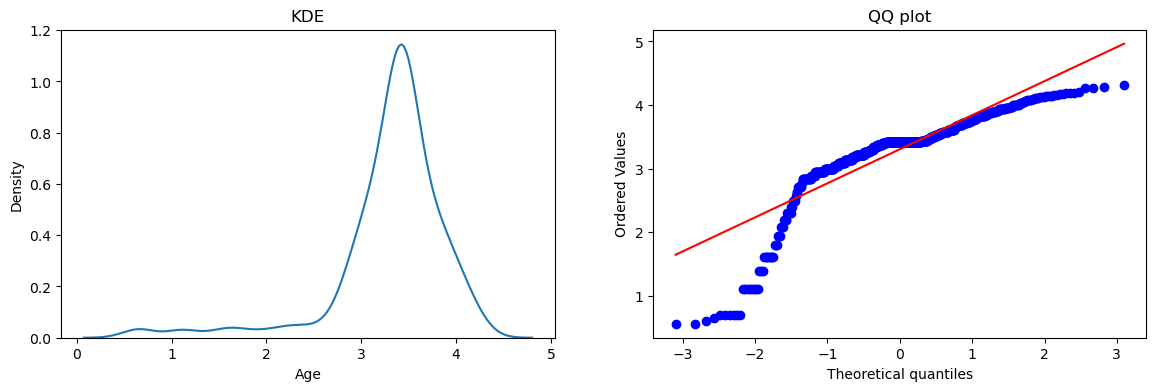

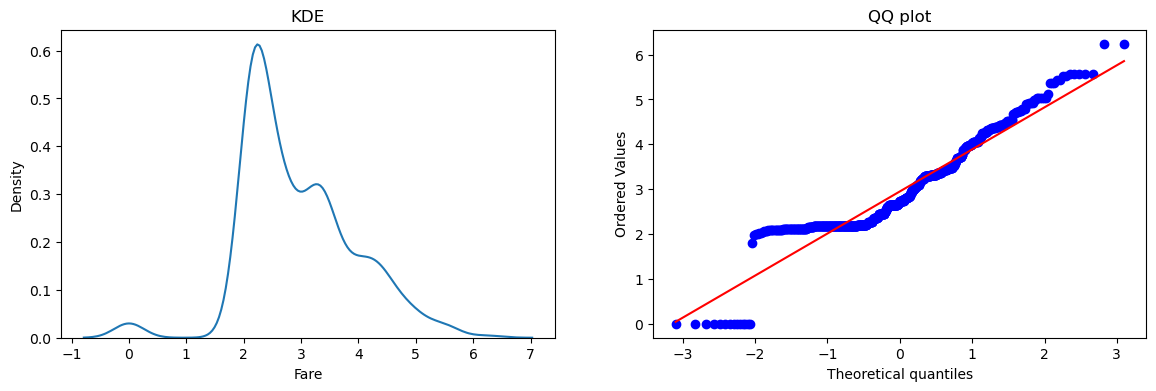

In [32]:
for i in colsx: 
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.kdeplot(X_train_tr[i])
    plt.title("KDE")

    plt.subplot(122)
    stats.probplot(X_train_tr[i],dist='norm',plot=plt)
    plt.title("QQ plot")

In [33]:
mod3=LogisticRegression()
mod4=DecisionTreeClassifier()

mod3.fit(X_train_tr,Y_train)
mod4.fit(X_train_tr,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
pred3=mod3.predict(X_test_tr)
pred4=mod4.predict(X_test_tr)

print("Accuracy of LR :",accuracy_score(Y_test,pred3))
print("Accuracy of DTC",accuracy_score(Y_test,pred4))


Accuracy of LR : 0.6983240223463687
Accuracy of DTC 0.6033519553072626


In [36]:
LOR=LogisticRegression()
DTC=DecisionTreeClassifier()

X_trans=trf.transform(X)
print("LR : ",np.mean(cross_val_score(LOR,X_trans,Y,scoring="accuracy",cv=10)))
print("DT : ",np.mean(cross_val_score(DTC,X_trans,Y,scoring="accuracy",cv=10)))


LR :  0.678027465667915
DT :  0.663370786516854
